# 02 — Qualidade dos Dados

Este notebook realiza a **auditoria da qualidade do dataset consolidado** produzido na etapa anterior.

O objetivo é conhecer a estrutura da base, identificar inconsistências relevantes para a modelagem e produzir evidências descritivas que possam subsidiar a seção de **Resultados e Discussões** do artigo.

### Escopo desta etapa

Serão analisados:

- dimensão e estrutura da base;
- tipos de dados;
- valores ausentes;
- registros duplicados;
- cardinalidade e variáveis constantes;
- distribuição da variável-alvo;
- composição da amostra supervisionada;
- continuidade temporal dos 48 meses;
- evolução mensal do volume de reclamações;
- evolução temporal da classe positiva `Resolvida`.

> **Importante:** este notebook é exclusivamente diagnóstico. Nenhum registro é removido, imputado ou recodificado nesta etapa.


## 1. Bibliotecas e configurações


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Diretórios do projeto

Os dados permanecem fora do versionamento no GitHub, enquanto tabelas e figuras podem ser exportadas para a pasta `outputs`.


In [2]:
PROJECT_DIR = Path(r"C:\UnB\script_md")
BASE_DIR = PROJECT_DIR / "Base de dados"
PROCESSADOS_DIR = BASE_DIR / "processados"

FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Aceita os dois nomes utilizados durante a construção do projeto.
candidatos = [
    PROCESSADOS_DIR / "dataset.csv",
    PROCESSADOS_DIR / "dataset_banco_brasil_puro.csv",
]

INPUT_FILE = next((arquivo for arquivo in candidatos if arquivo.exists()), None)

if INPUT_FILE is None:
    raise FileNotFoundError(
        "Nenhum dataset consolidado foi encontrado em "
        f"{PROCESSADOS_DIR}. Arquivos procurados: "
        + ", ".join(arquivo.name for arquivo in candidatos)
    )

print(f"Dataset: {INPUT_FILE}")
print(f"Figuras: {FIGURES_DIR}")
print(f"Tabelas: {TABLES_DIR}")


Dataset: C:\UnB\script_md\Base de dados\processados\dataset.csv
Figuras: C:\UnB\script_md\outputs\figuras
Tabelas: C:\UnB\script_md\outputs\tabelas


## 3. Carregamento do dataset


In [3]:
df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Dimensão da base: {df.shape[0]:,} linhas x {df.shape[1]} colunas")


Dimensão da base: 209,870 linhas x 22 colunas


## 4. Funções auxiliares

As funções abaixo concentram operações que seriam repetidas em diferentes pontos do notebook.


In [4]:
def localizar_coluna(dataframe, nome_esperado):
    """Localiza uma coluna ignorando espaços duplicados no cabeçalho."""
    alvo = " ".join(nome_esperado.split())

    for coluna in dataframe.columns:
        if " ".join(str(coluna).split()) == alvo:
            return coluna

    raise KeyError(f"Coluna '{nome_esperado}' não encontrada.")


def tabela_frequencia(serie, ordem=None):
    """Retorna frequência absoluta e percentual de uma série categórica."""
    frequencia = serie.value_counts(dropna=False)
    percentual = serie.value_counts(dropna=False, normalize=True).mul(100)

    resultado = pd.DataFrame({
        "Frequência": frequencia,
        "Percentual (%)": percentual.round(2)
    })

    if ordem is not None:
        ordem_existente = [valor for valor in ordem if valor in resultado.index]
        demais = [valor for valor in resultado.index if valor not in ordem_existente]
        resultado = resultado.reindex(ordem_existente + demais)

    return resultado


def salvar_tabela(dataframe, nome_arquivo, index=True):
    """Exporta uma tabela em CSV com configuração compatível com Excel/Windows."""
    caminho = TABLES_DIR / nome_arquivo
    dataframe.to_csv(
        caminho,
        sep=";",
        encoding="utf-8-sig",
        index=index
    )
    return caminho


## 5. Estrutura geral da base

Primeiro verificamos colunas, tipos inferidos pelo pandas e uma amostra dos registros.


In [5]:
print("Colunas disponíveis:")
display(pd.DataFrame({"Variável": df.columns}))

print("\nTipos de dados:")
display(
    df.dtypes.astype(str)
      .rename("Tipo")
      .to_frame()
)

display(df.head())


Colunas disponíveis:


,Variável
0,Região
1,UF
2,Cidade
3,Sexo
4,Faixa Etária
5,Data Finalização
6,Tempo Resposta
7,Nome Fantasia
8,Segmento de Mercado
9,Área



Tipos de dados:


,Tipo
Região,str
UF,str
Cidade,str
Sexo,str
Faixa Etária,str
Data Finalização,str
Tempo Resposta,float64
Nome Fantasia,str
Segmento de Mercado,str
Área,str


,Região,UF,Cidade,Sexo,Faixa Etária,Data Finalização,Tempo Resposta,Nome Fantasia,Segmento de Mercado,Área,Assunto,Grupo Problema,Problema,Como Comprou Contratou,Procurou Empresa,Respondida,Situação,Avaliação Reclamação,Nota do Consumidor,Interação com Judiciario,Último Complemento Consumidor,AAAA_MM
0,N,AM,Manaus,F,entre 51 a 60 anos,2022-08-04,10.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Crédito Consignado (para servidores públicos ou trabalhadores do setor privado),Contrato / Oferta,Não entrega do contrato ou documentação relacionada ao serviço,Loja física,S,S,Finalizada avaliada,Não Resolvida,2.00,NaN,NaN,2022_08
1,SE,SP,São Paulo,M,entre 61 a 70 anos,2022-08-05,10.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Crédito Pessoal e Demais Empréstimos (exceto financiamento de imóveis e veículos),Contrato / Oferta,Alteração / rescisão de contrato sem solicitação / aviso prévio,Não comprei / contratei,S,S,Finalizada avaliada,Não Resolvida,2.00,NaN,NaN,2022_08
2,SE,SP,Jundiaí,M,entre 51 a 60 anos,2022-08-11,10.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Crédito Consignado / Cartão de Crédito Consignado / RMC (para beneficiários do INSS),Cobrança / Contestação,Cobrança por serviço/produto não contratado / não reconhecido / não solicitado,Não comprei / contratei,S,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2022_08
3,SE,RJ,Rio de Janeiro,M,entre 61 a 70 anos,2022-08-04,9.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Crédito Consignado / Cartão de Crédito Consignado / RMC (para beneficiários do INSS),Cobrança / Contestação,Cobrança por serviço/produto não contratado / não reconhecido / não solicitado,SMS / Mensagem de texto,S,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2022_08
4,SE,ES,Vitória,F,entre 41 a 50 anos,2022-08-08,8.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Crédito Pessoal e Demais Empréstimos (exceto financiamento de imóveis e veículos),Cobrança / Contestação,Cobrança indevida / abusiva para alterar ou cancelar o contrato,Telefone,N,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2022_08


## 6. Resumo da qualidade dos dados

Nesta seção reunimos, em uma única tabela, quantidade de ausências, percentual de ausências, cardinalidade e tipo de cada variável.


In [6]:
resumo_variaveis = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Nulos": df.isna().sum(),
    "Nulos (%)": df.isna().mean().mul(100).round(2),
    "Valores únicos": df.nunique(dropna=False)
})

resumo_variaveis = resumo_variaveis.sort_values(
    by=["Nulos (%)", "Valores únicos"],
    ascending=[False, True]
)

display(resumo_variaveis)

salvar_tabela(
    resumo_variaveis,
    "resumo_qualidade_variaveis.csv"
)


,Tipo,Nulos,Nulos (%),Valores únicos
Último Complemento Consumidor,str,205208,97.78,64
Interação com Judiciario,str,202034,96.27,3
Nota do Consumidor,float64,151739,72.30,6
Nome Fantasia,str,0,0.00,1
Segmento de Mercado,str,0,0.00,1
Procurou Empresa,str,0,0.00,2
Respondida,str,0,0.00,2
Situação,str,0,0.00,2
Área,str,0,0.00,3
Avaliação Reclamação,str,0,0.00,3


WindowsPath('C:/UnB/script_md/outputs/tabelas/resumo_qualidade_variaveis.csv')

### 6.1 Variáveis com valores ausentes


In [7]:
variaveis_com_nulos = resumo_variaveis[
    resumo_variaveis["Nulos"] > 0
].copy()

display(variaveis_com_nulos)


,Tipo,Nulos,Nulos (%),Valores únicos
Último Complemento Consumidor,str,205208,97.78,64
Interação com Judiciario,str,202034,96.27,3
Nota do Consumidor,float64,151739,72.30,6
Sexo,str,2,0.00,4
Tempo Resposta,float64,9,0.00,17


### 6.2 Visualização dos percentuais de ausência

O gráfico é gerado somente para variáveis que possuem pelo menos um valor ausente.


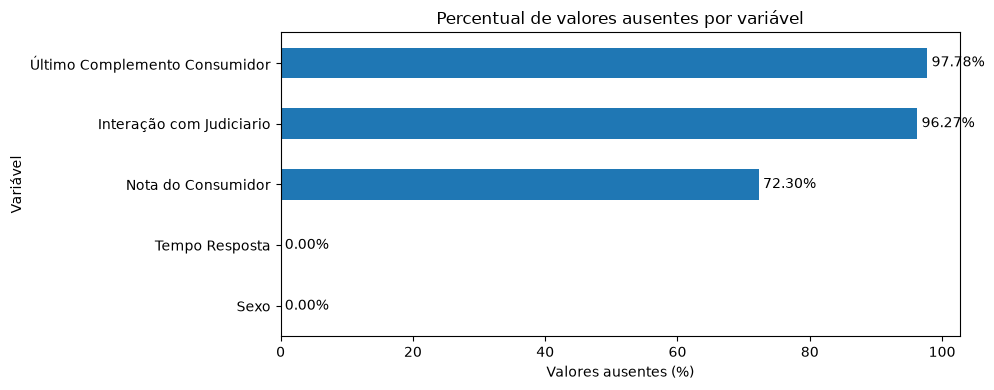

In [8]:
if not variaveis_com_nulos.empty:
    dados_plot = variaveis_com_nulos["Nulos (%)"].sort_values()

    fig, ax = plt.subplots(figsize=(10, max(4, len(dados_plot) * 0.45)))

    dados_plot.plot(
        kind="barh",
        ax=ax
    )

    ax.set_title("Percentual de valores ausentes por variável")
    ax.set_xlabel("Valores ausentes (%)")
    ax.set_ylabel("Variável")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=3)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / "percentual_valores_ausentes.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
else:
    print("Não foram identificados valores ausentes na base.")


## 7. Registros duplicados

A duplicidade é verificada considerando todas as colunas do dataset. A presença de duplicatas não implica automaticamente erro, portanto nenhuma linha é removida nesta etapa.


In [9]:
qtd_duplicados = int(df.duplicated().sum())
pct_duplicados = qtd_duplicados / len(df) * 100

print(f"Registros duplicados: {qtd_duplicados:,}")
print(f"Percentual de duplicados: {pct_duplicados:.2f}%")

if qtd_duplicados > 0:
    display(df[df.duplicated(keep=False)].head(20))


Registros duplicados: 1,180
Percentual de duplicados: 0.56%


,Região,UF,Cidade,Sexo,Faixa Etária,Data Finalização,Tempo Resposta,Nome Fantasia,Segmento de Mercado,Área,Assunto,Grupo Problema,Problema,Como Comprou Contratou,Procurou Empresa,Respondida,Situação,Avaliação Reclamação,Nota do Consumidor,Interação com Judiciario,Último Complemento Consumidor,AAAA_MM
1760,NE,PI,Água Branca,F,entre 51 a 60 anos,2022-10-13,7.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Conta corrente / Salário / Poupança /Conta Aposentadoria,Cobrança / Contestação,Cobrança por serviço/produto não contratado / não reconhecido / não solicitado,Não comprei / contratei,S,S,Finalizada avaliada,Não Resolvida,1.00,NaN,NaN,2022_10
1782,NE,PI,Água Branca,F,entre 51 a 60 anos,2022-10-13,7.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Conta corrente / Salário / Poupança /Conta Aposentadoria,Cobrança / Contestação,Cobrança por serviço/produto não contratado / não reconhecido / não solicitado,Não comprei / contratei,S,S,Finalizada avaliada,Não Resolvida,1.00,NaN,NaN,2022_10
6465,SE,ES,Vitória,F,entre 21 a 30 anos,2023-03-31,6.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Cartão de Crédito / Cartão de Débito / Cartão de Loja,Cobrança / Contestação,Renegociação / parcelamento de dívida,Internet,S,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2023_03
6503,SE,ES,Vitória,F,entre 21 a 30 anos,2023-03-31,6.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Cartão de Crédito / Cartão de Débito / Cartão de Loja,Cobrança / Contestação,Renegociação / parcelamento de dívida,Internet,S,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2023_03
9023,CO,GO,Bom Jesus,M,entre 31 a 40 anos,2023-05-19,2.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Crédito Pessoal e Demais Empréstimos (exceto financiamento de imóveis e veículos),Contrato / Oferta,Não entrega do contrato ou documentação relacionada ao serviço,Loja física,S,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2023_05
9024,CO,GO,Bom Jesus,M,entre 31 a 40 anos,2023-05-19,2.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Crédito Pessoal e Demais Empréstimos (exceto financiamento de imóveis e veículos),Contrato / Oferta,Não entrega do contrato ou documentação relacionada ao serviço,Loja física,S,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2023_05
10746,SE,RJ,Rio de Janeiro,F,mais de 70 anos,2023-07-03,5.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Conta corrente / Salário / Poupança /Conta Aposentadoria,Cobrança / Contestação,"Cobrança de tarifas, taxas, valores não previstos / não informados",Loja física,S,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2023_07
10747,SE,RJ,Rio de Janeiro,F,mais de 70 anos,2023-07-03,5.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Conta corrente / Salário / Poupança /Conta Aposentadoria,Cobrança / Contestação,"Cobrança de tarifas, taxas, valores não previstos / não informados",Loja física,S,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2023_07
15967,NE,CE,Barro,F,entre 41 a 50 anos,2023-10-03,10.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Seguro Prestamista,Cobrança / Contestação,"Cobrança de tarifas, taxas, valores não previstos / não informados",Não comprei / contratei,N,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2023_10
15968,NE,CE,Barro,F,entre 41 a 50 anos,2023-10-03,10.00,Banco do Brasil,"Bancos, Financeiras e Administradoras de Cartão",Serviços Financeiros,Seguro Prestamista,Cobrança / Contestação,"Cobrança de tarifas, taxas, valores não previstos / não informados",Não comprei / contratei,N,S,Finalizada não avaliada,Não Avaliada,NaN,NaN,NaN,2023_10


## 8. Cardinalidade e variáveis constantes

A cardinalidade ajuda a identificar variáveis sem poder discriminante e variáveis categóricas potencialmente complexas para codificação.


In [10]:
cardinalidade = (
    resumo_variaveis[["Tipo", "Valores únicos"]]
    .sort_values("Valores únicos")
)

display(cardinalidade)

variaveis_constantes = cardinalidade[
    cardinalidade["Valores únicos"] == 1
].index.tolist()

print("Variáveis constantes:")
print(variaveis_constantes)


,Tipo,Valores únicos
Nome Fantasia,str,1
Segmento de Mercado,str,1
Procurou Empresa,str,2
Respondida,str,2
Situação,str,2
Interação com Judiciario,str,3
Avaliação Reclamação,str,3
Área,str,3
Sexo,str,4
Região,str,5


Variáveis constantes:
['Nome Fantasia', 'Segmento de Mercado']


## 9. Auditoria da variável-alvo

A variável-alvo original possui três categorias esperadas:

- `Resolvida`;
- `Não Resolvida`;
- `Não Avaliada`.

Para a futura modelagem supervisionada, apenas `Resolvida` e `Não Resolvida` serão consideradas. Nesta etapa, porém, nenhuma observação é excluída da base original.


In [11]:
COL_TARGET = localizar_coluna(df, "Avaliação Reclamação")

categorias_esperadas = {
    "Resolvida",
    "Não Resolvida",
    "Não Avaliada"
}

categorias_observadas = set(
    df[COL_TARGET]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

categorias_inesperadas = categorias_observadas - categorias_esperadas

print(f"Coluna-alvo localizada como: {COL_TARGET!r}")
print(f"Categorias observadas: {sorted(categorias_observadas)}")
print(f"Categorias inesperadas: {sorted(categorias_inesperadas)}")


Coluna-alvo localizada como: 'Avaliação Reclamação'
Categorias observadas: ['Não Avaliada', 'Não Resolvida', 'Resolvida']
Categorias inesperadas: []


### 9.1 Distribuição da variável-alvo na base completa


In [12]:
distribuicao_target_completa = tabela_frequencia(
    df[COL_TARGET],
    ordem=["Resolvida", "Não Resolvida", "Não Avaliada"]
)

display(distribuicao_target_completa)

salvar_tabela(
    distribuicao_target_completa,
    "distribuicao_variavel_alvo_base_completa.csv"
)


,Frequência,Percentual (%)
Avaliação Reclamação,,
Resolvida,20050,9.55
Não Resolvida,38081,18.15
Não Avaliada,151739,72.30


WindowsPath('C:/UnB/script_md/outputs/tabelas/distribuicao_variavel_alvo_base_completa.csv')

### 9.2 Amostra supervisionada

A amostra supervisionada é definida apenas para fins de diagnóstico, mantendo as categorias com desfecho conhecido.


In [13]:
df_avaliadas = df[
    df[COL_TARGET].isin(["Resolvida", "Não Resolvida"])
].copy()

distribuicao_supervisionada = tabela_frequencia(
    df_avaliadas[COL_TARGET],
    ordem=["Resolvida", "Não Resolvida"]
)

display(distribuicao_supervisionada)

salvar_tabela(
    distribuicao_supervisionada,
    "distribuicao_variavel_alvo_supervisionada.csv"
)


,Frequência,Percentual (%)
Avaliação Reclamação,,
Resolvida,20050,34.49
Não Resolvida,38081,65.51


WindowsPath('C:/UnB/script_md/outputs/tabelas/distribuicao_variavel_alvo_supervisionada.csv')

### 9.3 Visualização da amostra supervisionada


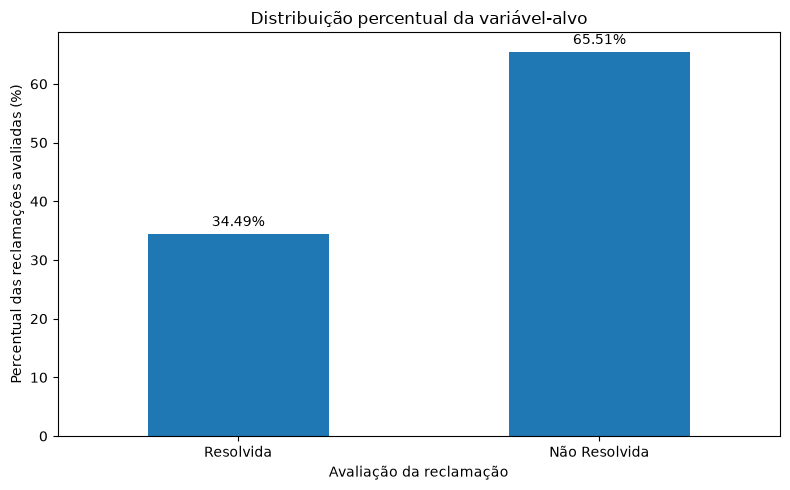

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

distribuicao_supervisionada["Percentual (%)"].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Distribuição percentual da variável-alvo")
ax.set_xlabel("Avaliação da reclamação")
ax.set_ylabel("Percentual das reclamações avaliadas (%)")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "distribuicao_percentual_variavel_alvo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 9.4 Síntese descritiva da variável-alvo


In [15]:
n_total = len(df)
n_avaliadas = len(df_avaliadas)
n_nao_avaliadas = int((df[COL_TARGET] == "Não Avaliada").sum())

n_resolvidas = int((df_avaliadas[COL_TARGET] == "Resolvida").sum())
n_nao_resolvidas = int((df_avaliadas[COL_TARGET] == "Não Resolvida").sum())

pct_avaliadas = n_avaliadas / n_total * 100
pct_nao_avaliadas = n_nao_avaliadas / n_total * 100

pct_resolvidas = n_resolvidas / n_avaliadas * 100
pct_nao_resolvidas = n_nao_resolvidas / n_avaliadas * 100

texto_target = (
    f"A base contém {n_total:,} reclamações. "
    f"Dessas, {n_avaliadas:,} ({pct_avaliadas:.2f}%) apresentam avaliação do consumidor, "
    f"enquanto {n_nao_avaliadas:,} ({pct_nao_avaliadas:.2f}%) correspondem a reclamações não avaliadas. "
    f"Entre as reclamações avaliadas, {n_resolvidas:,} ({pct_resolvidas:.2f}%) foram classificadas como "
    f"Resolvidas e {n_nao_resolvidas:,} ({pct_nao_resolvidas:.2f}%) como Não Resolvidas."
)

print(texto_target)


A base contém 209,870 reclamações. Dessas, 58,131 (27.70%) apresentam avaliação do consumidor, enquanto 151,739 (72.30%) correspondem a reclamações não avaliadas. Entre as reclamações avaliadas, 20,050 (34.49%) foram classificadas como Resolvidas e 38,081 (65.51%) como Não Resolvidas.


## 10. Auditoria temporal

A variável `AAAA_MM`, criada no notebook anterior, representa o ano e o mês de finalização da reclamação. Nesta seção verificamos sua consistência e a continuidade dos 48 meses analisados.


In [16]:
if "AAAA_MM" not in df.columns:
    raise KeyError("A coluna 'AAAA_MM' não foi encontrada no dataset.")

periodo_aux = pd.to_datetime(
    df["AAAA_MM"].astype(str).str.replace("_", "-", regex=False),
    format="%Y-%m",
    errors="coerce"
)

periodos_invalidos = int(periodo_aux.isna().sum())

inicio = periodo_aux.min().to_period("M")
fim = periodo_aux.max().to_period("M")

meses_esperados = pd.period_range(
    start=inicio,
    end=fim,
    freq="M"
)

meses_observados = pd.PeriodIndex(
    periodo_aux.dropna().dt.to_period("M").unique()
)

meses_ausentes = meses_esperados.difference(meses_observados)

print(f"Períodos não interpretados: {periodos_invalidos:,}")
print(f"Meses esperados:  {len(meses_esperados)}")
print(f"Meses observados: {len(meses_observados)}")
print(f"Período inicial:  {df['AAAA_MM'].min()}")
print(f"Período final:    {df['AAAA_MM'].max()}")
print(f"Meses ausentes:   {list(meses_ausentes)}")


Períodos não interpretados: 0
Meses esperados:  48
Meses observados: 48
Período inicial:  2022_08
Período final:    2026_07
Meses ausentes:   []


## 11. Evolução mensal do volume de reclamações


In [17]:
volume_mensal = (
    df.groupby("AAAA_MM")
      .size()
      .rename("Quantidade")
      .reset_index()
      .sort_values("AAAA_MM")
)

volume_mensal["Percentual (%)"] = (
    volume_mensal["Quantidade"]
    .div(volume_mensal["Quantidade"].sum())
    .mul(100)
    .round(2)
)

display(volume_mensal)

salvar_tabela(
    volume_mensal,
    "volume_mensal_reclamacoes.csv",
    index=False
)


,AAAA_MM,Quantidade,Percentual (%)
0,2022_08,770,0.37
1,2022_09,801,0.38
2,2022_10,720,0.34
3,2022_11,816,0.39
4,2022_12,1170,0.56
5,2023_01,798,0.38
6,2023_02,604,0.29
7,2023_03,1512,0.72
8,2023_04,1296,0.62
9,2023_05,952,0.45


WindowsPath('C:/UnB/script_md/outputs/tabelas/volume_mensal_reclamacoes.csv')

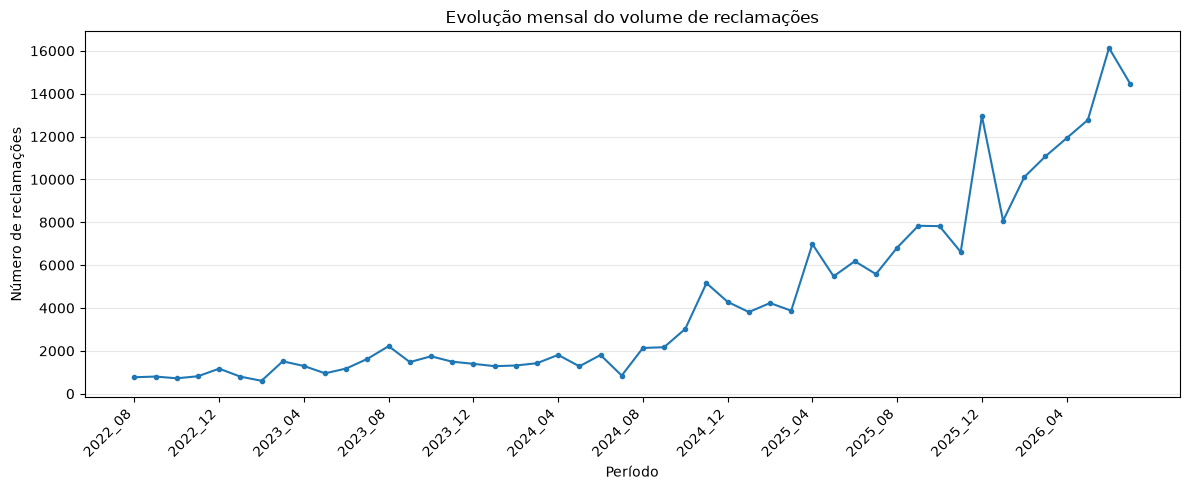

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    volume_mensal["AAAA_MM"],
    volume_mensal["Quantidade"],
    marker="o",
    markersize=3
)

ax.set_title("Evolução mensal do volume de reclamações")
ax.set_xlabel("Período")
ax.set_ylabel("Número de reclamações")

passo_rotulo = 4
posicoes = list(range(0, len(volume_mensal), passo_rotulo))

ax.set_xticks(posicoes)
ax.set_xticklabels(
    volume_mensal["AAAA_MM"].iloc[posicoes],
    rotation=45,
    ha="right"
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "evolucao_volume_mensal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 11.1 Síntese do volume mensal


In [19]:
mes_maior_volume = volume_mensal.loc[
    volume_mensal["Quantidade"].idxmax()
]

mes_menor_volume = volume_mensal.loc[
    volume_mensal["Quantidade"].idxmin()
]

print(
    f"O menor volume mensal foi observado em {mes_menor_volume['AAAA_MM']}, "
    f"com {int(mes_menor_volume['Quantidade']):,} reclamações."
)

print(
    f"O maior volume mensal foi observado em {mes_maior_volume['AAAA_MM']}, "
    f"com {int(mes_maior_volume['Quantidade']):,} reclamações."
)


O menor volume mensal foi observado em 2023_02, com 604 reclamações.
O maior volume mensal foi observado em 2026_06, com 16,132 reclamações.


## 12. Evolução temporal da variável-alvo

A distribuição mensal é analisada de duas formas:

1. composição das três categorias na base completa;
2. proporção de `Resolvida` e `Não Resolvida` considerando apenas as reclamações avaliadas.


In [20]:
target_mensal = (
    df.groupby(["AAAA_MM", COL_TARGET])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

# Garante a existência das colunas esperadas mesmo que alguma classe não apareça em determinado recorte.
for classe in ["Resolvida", "Não Resolvida", "Não Avaliada"]:
    if classe not in target_mensal.columns:
        target_mensal[classe] = 0

target_mensal = target_mensal[
    ["Resolvida", "Não Resolvida", "Não Avaliada"]
]

target_mensal["Total"] = target_mensal.sum(axis=1)

display(target_mensal)

salvar_tabela(
    target_mensal,
    "distribuicao_target_mensal_absoluta.csv"
)


Avaliação Reclamação,Resolvida,Não Resolvida,Não Avaliada,Total
AAAA_MM,,,,
2022_08,199,154,417,770
2022_09,215,183,403,801
2022_10,175,148,397,720
2022_11,189,208,419,816
2022_12,211,179,780,1170
2023_01,188,172,438,798
2023_02,150,147,307,604
2023_03,245,409,858,1512
2023_04,196,258,842,1296


WindowsPath('C:/UnB/script_md/outputs/tabelas/distribuicao_target_mensal_absoluta.csv')

### 12.1 Distribuição percentual das três categorias


In [21]:
target_mensal_pct = (
    target_mensal[["Resolvida", "Não Resolvida", "Não Avaliada"]]
    .div(target_mensal["Total"], axis=0)
    .mul(100)
    .round(2)
)

display(target_mensal_pct)

salvar_tabela(
    target_mensal_pct,
    "distribuicao_target_mensal_percentual.csv"
)


Avaliação Reclamação,Resolvida,Não Resolvida,Não Avaliada
AAAA_MM,,,
2022_08,25.84,20.00,54.16
2022_09,26.84,22.85,50.31
2022_10,24.31,20.56,55.14
2022_11,23.16,25.49,51.35
2022_12,18.03,15.30,66.67
2023_01,23.56,21.55,54.89
2023_02,24.83,24.34,50.83
2023_03,16.20,27.05,56.75
2023_04,15.12,19.91,64.97


WindowsPath('C:/UnB/script_md/outputs/tabelas/distribuicao_target_mensal_percentual.csv')

### 12.2 Evolução da amostra supervisionada

Aqui analisamos apenas as reclamações com avaliação conhecida.


In [22]:
target_avaliada_mensal = target_mensal[
    ["Resolvida", "Não Resolvida"]
].copy()

target_avaliada_mensal["Total Avaliadas"] = (
    target_avaliada_mensal["Resolvida"] +
    target_avaliada_mensal["Não Resolvida"]
)

target_avaliada_mensal["Resolvida (%)"] = (
    target_avaliada_mensal["Resolvida"]
    .div(target_avaliada_mensal["Total Avaliadas"])
    .mul(100)
    .round(2)
)

target_avaliada_mensal["Não Resolvida (%)"] = (
    target_avaliada_mensal["Não Resolvida"]
    .div(target_avaliada_mensal["Total Avaliadas"])
    .mul(100)
    .round(2)
)

display(target_avaliada_mensal)

salvar_tabela(
    target_avaliada_mensal,
    "target_supervisionada_por_mes.csv"
)


Avaliação Reclamação,Resolvida,Não Resolvida,Total Avaliadas,Resolvida (%),Não Resolvida (%)
AAAA_MM,,,,,
2022_08,199,154,353,56.37,43.63
2022_09,215,183,398,54.02,45.98
2022_10,175,148,323,54.18,45.82
2022_11,189,208,397,47.61,52.39
2022_12,211,179,390,54.10,45.90
2023_01,188,172,360,52.22,47.78
2023_02,150,147,297,50.51,49.49
2023_03,245,409,654,37.46,62.54
2023_04,196,258,454,43.17,56.83


WindowsPath('C:/UnB/script_md/outputs/tabelas/target_supervisionada_por_mes.csv')

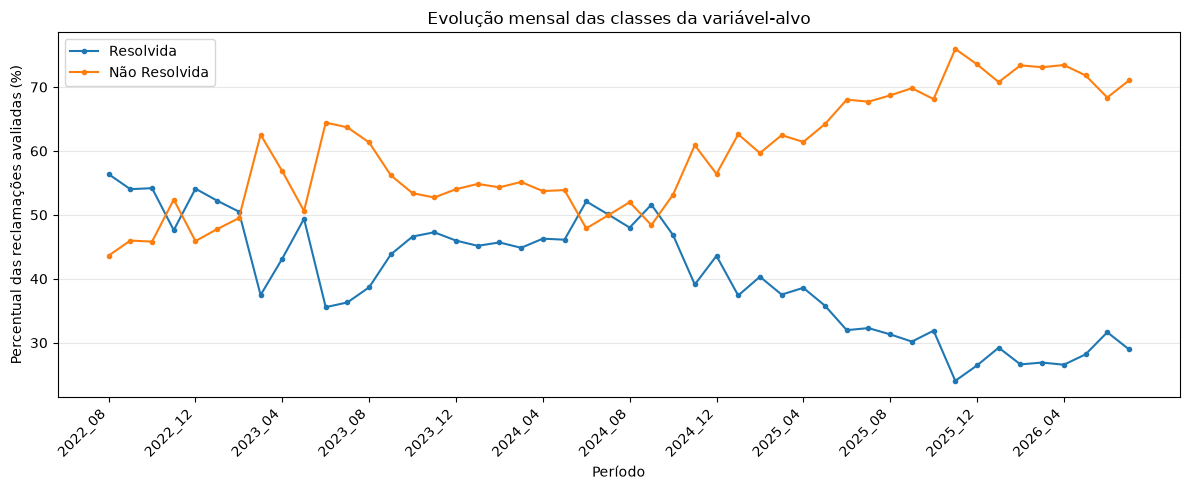

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    target_avaliada_mensal.index,
    target_avaliada_mensal["Resolvida (%)"],
    marker="o",
    markersize=3,
    label="Resolvida"
)

ax.plot(
    target_avaliada_mensal.index,
    target_avaliada_mensal["Não Resolvida (%)"],
    marker="o",
    markersize=3,
    label="Não Resolvida"
)

ax.set_title("Evolução mensal das classes da variável-alvo")
ax.set_xlabel("Período")
ax.set_ylabel("Percentual das reclamações avaliadas (%)")

passo_rotulo = 4
posicoes = list(range(0, len(target_avaliada_mensal), passo_rotulo))

ax.set_xticks(posicoes)
ax.set_xticklabels(
    target_avaliada_mensal.index[posicoes],
    rotation=45,
    ha="right"
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "evolucao_classes_target.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 12.3 Síntese da estabilidade temporal da classe positiva


In [24]:
serie_resolvida = target_avaliada_mensal["Resolvida (%)"]

media_resolvida = serie_resolvida.mean()
desvio_resolvida = serie_resolvida.std()
min_resolvida = serie_resolvida.min()
max_resolvida = serie_resolvida.max()

mes_min = serie_resolvida.idxmin()
mes_max = serie_resolvida.idxmax()

print(
    f"A proporção média mensal de reclamações Resolvidas entre as avaliadas "
    f"foi de {media_resolvida:.2f}% (desvio-padrão de {desvio_resolvida:.2f} p.p.)."
)

print(
    f"O menor percentual ocorreu em {mes_min}, com {min_resolvida:.2f}%."
)

print(
    f"O maior percentual ocorreu em {mes_max}, com {max_resolvida:.2f}%."
)


A proporção média mensal de reclamações Resolvidas entre as avaliadas foi de 40.59% (desvio-padrão de 9.14 p.p.).
O menor percentual ocorreu em 2025_11, com 24.04%.
O maior percentual ocorreu em 2022_08, com 56.37%.


## 13. Resumo consolidado da qualidade da base

Este quadro concentra os principais números necessários para decidir os tratamentos da próxima etapa.


In [25]:
resumo_qualidade = pd.DataFrame({
    "Indicador": [
        "Quantidade de registros",
        "Quantidade de variáveis",
        "Variáveis com valores ausentes",
        "Registros duplicados",
        "Duplicados (%)",
        "Variáveis constantes",
        "Meses observados",
        "Meses ausentes",
        "Período inicial",
        "Período final",
        "Reclamações avaliadas",
        "Reclamações não avaliadas",
        "Resolvidas entre avaliadas (%)",
        "Não Resolvidas entre avaliadas (%)"
    ],
    "Valor": [
        f"{len(df):,}",
        df.shape[1],
        int((df.isna().sum() > 0).sum()),
        f"{qtd_duplicados:,}",
        f"{pct_duplicados:.2f}%",
        len(variaveis_constantes),
        len(meses_observados),
        len(meses_ausentes),
        df["AAAA_MM"].min(),
        df["AAAA_MM"].max(),
        f"{n_avaliadas:,}",
        f"{n_nao_avaliadas:,}",
        f"{pct_resolvidas:.2f}%",
        f"{pct_nao_resolvidas:.2f}%"
    ]
})

display(resumo_qualidade)

salvar_tabela(
    resumo_qualidade,
    "resumo_consolidado_qualidade.csv",
    index=False
)


,Indicador,Valor
0,Quantidade de registros,"209,870"
1,Quantidade de variáveis,22
2,Variáveis com valores ausentes,5
3,Registros duplicados,"1,180"
4,Duplicados (%),0.56%
5,Variáveis constantes,2
6,Meses observados,48
7,Meses ausentes,0
8,Período inicial,2022_08
9,Período final,2026_07


WindowsPath('C:/UnB/script_md/outputs/tabelas/resumo_consolidado_qualidade.csv')

## 14. Síntese para apoio a Resultados e Discussões

O texto abaixo é gerado automaticamente a partir dos resultados observados. Ele funciona como apoio à redação científica e deve ser posteriormente revisado à luz das decisões metodológicas e dos resultados dos modelos.


In [26]:
sintese = (
    f"A base consolidada contém {len(df):,} registros e {df.shape[1]} variáveis, "
    f"distribuídos continuamente entre {df['AAAA_MM'].min()} e {df['AAAA_MM'].max()}, "
    f"sem lacunas mensais no período analisado. "
    f"Foram identificados {qtd_duplicados:,} registros completamente duplicados "
    f"({pct_duplicados:.2f}% da base), cuja natureza deverá ser avaliada antes de eventual exclusão. "
    f"Quanto à variável-alvo, {n_avaliadas:,} reclamações apresentam avaliação conhecida. "
    f"Entre essas observações, {pct_resolvidas:.2f}% foram classificadas como Resolvidas "
    f"e {pct_nao_resolvidas:.2f}% como Não Resolvidas. "
    f"A proporção mensal da classe Resolvida variou entre {min_resolvida:.2f}% e "
    f"{max_resolvida:.2f}% ao longo do período, com média de {media_resolvida:.2f}%."
)

print(sintese)


A base consolidada contém 209,870 registros e 22 variáveis, distribuídos continuamente entre 2022_08 e 2026_07, sem lacunas mensais no período analisado. Foram identificados 1,180 registros completamente duplicados (0.56% da base), cuja natureza deverá ser avaliada antes de eventual exclusão. Quanto à variável-alvo, 58,131 reclamações apresentam avaliação conhecida. Entre essas observações, 34.49% foram classificadas como Resolvidas e 65.51% como Não Resolvidas. A proporção mensal da classe Resolvida variou entre 24.04% e 56.37% ao longo do período, com média de 40.59%.


## 15. Próxima etapa

Com a auditoria concluída, o próximo notebook deverá preparar efetivamente os dados para modelagem, incluindo:

- definição formal da amostra supervisionada;
- tratamento de registros duplicados, se justificado;
- avaliação das variáveis com risco de *data leakage*;
- exclusão de variáveis constantes ou sem utilidade preditiva;
- tratamento de valores ausentes;
- preparação das variáveis categóricas;
- definição do particionamento temporal em treino, teste e *out-of-time*.

As decisões da próxima etapa deverão ser justificadas com base nos resultados deste notebook.
